In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('../3/train.csv', usecols=['PassengerId', 'Survived', 'Pclass', 'Age'])

In [10]:
df.head()

,PassengerId,Survived,Pclass,Age
0,1,0,3,22.0
1,2,1,1,38.0
2,3,1,3,26.0
3,4,1,1,35.0
4,5,0,3,35.0


In [11]:
df.describe()

,PassengerId,Survived,Pclass,Age
count,891.000000,891.000000,891.000000,714.000000
mean,446.000000,0.383838,2.308642,29.699118
std,257.353842,0.486592,0.836071,14.526497
min,1.000000,0.000000,1.000000,0.420000
25%,223.500000,0.000000,2.000000,20.125000
50%,446.000000,0.000000,3.000000,28.000000
75%,668.500000,1.000000,3.000000,38.000000
max,891.000000,1.000000,3.000000,80.000000


<Axes: ylabel='Age'>

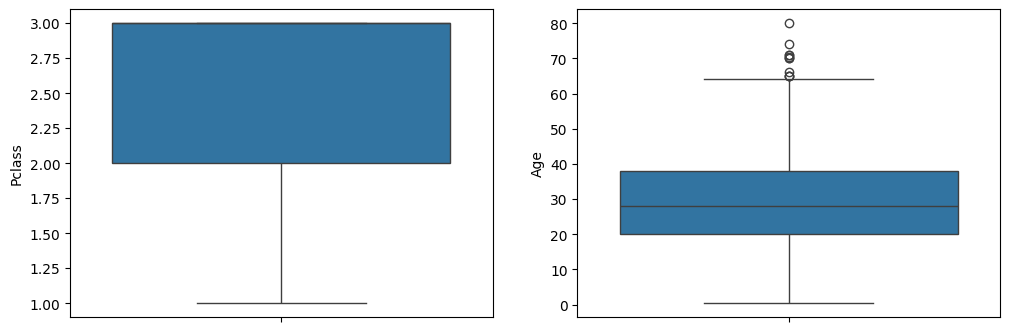

In [17]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(df['Pclass'])

plt.subplot(1, 2, 2)
sns.boxplot(df['Age'])

In [19]:
upper_limit = df['Age'].quantile(0.99)
upper_limit

np.float64(65.87)

In [20]:
lower_limit = df['Age'].quantile(0.01)
lower_limit

np.float64(1.0)

In [22]:
new_df = df[(df['Age'] <= 65.87) & (df['Age'] >= 1.0)]
new_df

,PassengerId,Survived,Pclass,Age
0,1,0,3,22.0
1,2,1,1,38.0
2,3,1,3,26.0
3,4,1,1,35.0
4,5,0,3,35.0
...,...,...,...,...
885,886,0,3,39.0
886,887,0,2,27.0
887,888,1,1,19.0
889,890,1,1,26.0


In [23]:
new_df['Age'].describe()

count    699.000000
mean      29.510014
std       13.669525
min        1.000000
25%       21.000000
50%       28.000000
75%       38.000000
max       65.000000
Name: Age, dtype: float64

In [24]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

C:\Users\harsh\AppData\Local\Temp\ipykernel_9992\366217279.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

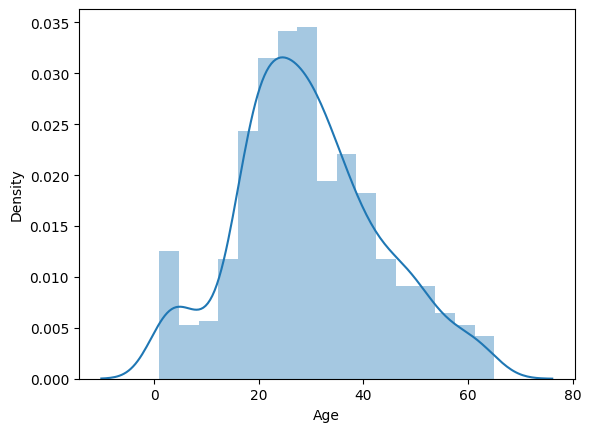

In [25]:
sns.distplot(new_df['Age'])

<Axes: xlabel='Age'>

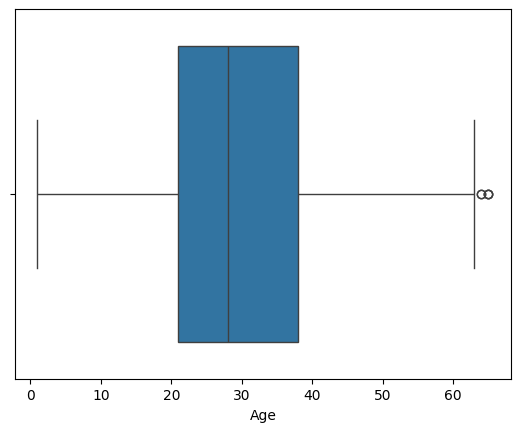

In [29]:
sns.boxplot(new_df['Age'], orient='h')

In [30]:
# Capping --> Winsorization

df['Age'] = np.where(
    df['Age'] >= upper_limit,
    upper_limit,
    np.where(
        df['Age'] <= lower_limit,
        lower_limit,
        df['Age']
    )
)

In [31]:
df.shape

(891, 4)

In [32]:
df['Age'].describe()

count    714.000000
mean      29.637899
std       14.343017
min        1.000000
25%       20.125000
50%       28.000000
75%       38.000000
max       65.870000
Name: Age, dtype: float64

C:\Users\harsh\AppData\Local\Temp\ipykernel_9992\3255828239.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

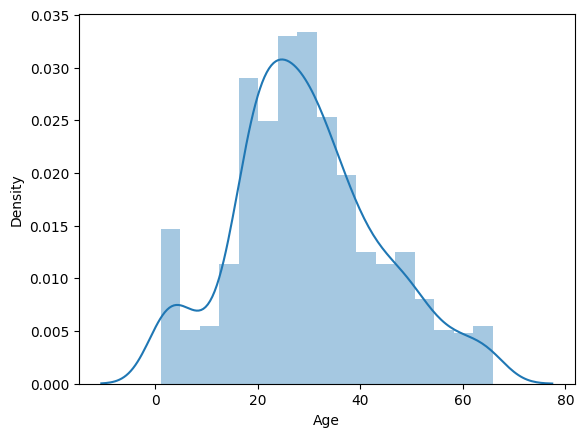

In [33]:
sns.distplot(df['Age'])

<Axes: xlabel='Age'>

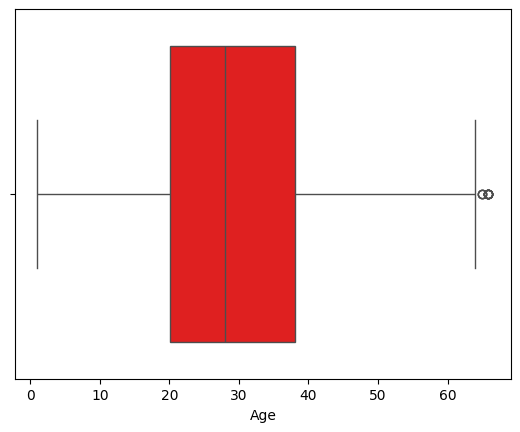

In [35]:
sns.boxplot(df['Age'], orient='h', color='Red')